Link to GitHub repository: https://github.com/Stampe04/CSS_Assignment2.git

All group members contributed equally to this project

# Part 1: Mixing Patterns and Assortativity

> __Exercise 1: Mixing Patterns and Assortativity__  
>
> __Part 1: Assortativity Coefficient__ 
> 1. *Calculate the Assortativity Coefficient* for the network based on the country of each node. Implement the calculation using the formula provided during the lecture, also available in [this paper](https://arxiv.org/pdf/cond-mat/0209450.pdf) (equation 2, here for directed networks). **Do not use the NetworkX implementation.**

Import the necessary packages:

In [4]:
import json
import networkx as nx
from collections import defaultdict
import random
import matplotlib.pyplot as plt
import numpy as np
import math

First we import the ```network_graph```.json file and load the data. Then we add the data (nodes, edges) to a graph using NetworkX.

In [5]:
with open("network_graph.json", "r", encoding="utf-8") as f:
    data = json.load(f)

G = nx.Graph()

# add nodes
for node in data["nodes"]:
    G.add_node(
        node["id"],
        name=node["display_name"],
        country=node["country_code"],
        citations=node["cited_by_count"],
        first_year=node["first_publication_year"]
    )

# add edges
for link in data["links"]:
    G.add_edge(
        link["source"],
        link["target"],
        weight=link["weight"]
    )

Before moving on, we compared the full network with the larget connected component. The results showed that there was not a huge difference. However, we still decided to continue the excercise with the largest connected component to save just a little time:

In [19]:
largest_cc = max(nx.connected_components(G), key=len)
G_gcc = G.subgraph(largest_cc).copy()

print(G.number_of_nodes(), G.number_of_edges())
print(G_gcc.number_of_nodes(), G_gcc.number_of_edges())

15023 51565
14323 50284


We were asked to calculate the *assortativity coefficient* using the formula either provided in the lecture or from the paper provided by the professor. We used the ```collections``` module and the ```defaultdict``` function to generate a dictionary to hold the values $a_i$ and $b_i$.

In [6]:
def attribute_assortativity_manual(G, attr):
    """
    Manual assortativity for a categorical node attribute on an undirected graph.
    Based on mixing matrix logic:
        r = (sum_i e_ii - sum_i a_i b_i) / (1 - sum_i a_i b_i)
    """
    mix = defaultdict(int)

    # Count attribute pair frequencies across edges
    for u, v in G.edges():
        au = G.nodes[u].get(attr)
        av = G.nodes[v].get(attr)

        if au is None or av is None:
            continue

        # For undirected graphs, count both directions
        mix[(au, av)] += 1
        mix[(av, au)] += 1

    M = sum(mix.values())
    e = {k: val / M for k, val in mix.items()}

    a = defaultdict(float)
    b = defaultdict(float)

    for (i, j), val in e.items():
        a[i] += val
        b[j] += val

    sum_eii = sum(val for (i, j), val in e.items() if i == j)
    labels = set(a) | set(b)
    sum_aibi = sum(a[k] * b[k] for k in labels)

    r = (sum_eii - sum_aibi) / (1 - sum_aibi)
    return r

The manually claculated country assortativity then becomes:

In [20]:
r_country = attribute_assortativity_manual(G_gcc, "country")
print("Manual country assortativity:", r_country)

Manual country assortativity: 0.38999650753281395


We also computed the value using the NetworkX implementation to cross-evaluate our own calculated results. the difference is quite small, so we deem it representable of the correct assortativity coefficient value.

In [21]:
r_country = nx.attribute_assortativity_coefficient(G_gcc, "country")
print(f"nx Country assortativity: {r_country:.3f}")

nx Country assortativity: 0.390


> __Part 2: Configuration model__
> In the following, we are going to assess the significance of the assortativity by comparing the network's assortativity coefficient against that of random networks generated through the configuration model.  
>
> 2. *Implement the configuration model* using the _double edge swap_ algorithm to generate random networks. Ensure each node retains its original degree but with altered connections. Create a function that does that by following these steps:
>
>   - **a.** Create an exact copy of your original network.
>   - **b.** Select two edges, $e_{1} = (u,v)$ and $e_{2} = (x,y)$, ensuring *u != y* and *v != x*.
>   - **c.** Flip the direction of $e_{1}$ to $e_{1} = (v,u)$ 50% of the time. This ensure that your final results is not biased, in case your edges were sorted (they usually are). 
>   - **d.** Ensure that new edges $e_{1}' = (e_{1}[0],e_{2}[1])$ and $e_{2}' = (e_{2}[0],e_{1}[1])$ do not already exist in the network.
>   - **e.** Remove edges $e_{1}$ and $e_{2}$ and add edges $e_{1}'$ and $e_{2}'$.
>   - **f.** Repeat steps **b** to **e** until you have performed $E\cdot10$ swaps, where E is the total number of edges.

We implemented the function below:

In [11]:
def canonical_edge(u, v):
    return (u, v) if u <= v else (v, u)

def double_edge_swap_configuration_model_fast(G, nswap=None, max_tries=None, seed=None):
    rng = random.Random(seed)
    H = G.copy()

    E = H.number_of_edges()
    if nswap is None:
        nswap = 10 * E
    if max_tries is None:
        max_tries = 20 * nswap

    # store edges in canonical form
    edge_list = [canonical_edge(u, v) for u, v in H.edges()]
    edge_pos = {e: i for i, e in enumerate(edge_list)}

    swaps = 0
    tries = 0

    while swaps < nswap and tries < max_tries:
        tries += 1

        i1, i2 = rng.sample(range(len(edge_list)), 2)
        e1 = edge_list[i1]
        e2 = edge_list[i2]

        u, v = e1
        x, y = e2

        # 50% flip of first edge
        if rng.random() < 0.5:
            u, v = v, u

        if u == y or v == x:
            continue

        new1 = canonical_edge(u, y)
        new2 = canonical_edge(x, v)

        # avoid self-loops
        if new1[0] == new1[1] or new2[0] == new2[1]:
            continue

        # avoid duplicate edges
        if new1 in edge_pos or new2 in edge_pos:
            continue

        # perform swap in graph
        H.remove_edge(*e1)
        H.remove_edge(*e2)
        H.add_edge(*new1)
        H.add_edge(*new2)

        # update edge_list + edge_pos in O(1)
        del edge_pos[e1]
        del edge_pos[e2]

        edge_list[i1] = new1
        edge_list[i2] = new2

        edge_pos[new1] = i1
        edge_pos[new2] = i2

        swaps += 1

    print(f"Successful swaps: {swaps}/{nswap}")
    print(f"Attempts: {tries}")
    return H

> 3. *Double check that your algorithm works well*, by showing that the degree of nodes in the original network and the new 'randomized' version of the network are the same.

Before testing our algorithm with 10*E swaps, we ran a quick sanity check with just 2000 swaps to ensure that it worked as expected. The results indicated that our implementation seemed to work:

In [13]:
G_rand = double_edge_swap_configuration_model_fast(G_gcc, nswap=2000, seed=42)
print(dict(G_gcc.degree()) == dict(G_rand.degree()))

Successful swaps: 2000/2000
Attempts: 2008
True


We then performed the full 10*E swaps. Our results showed that our implementation worked as expected:

In [14]:
def degree_dict(G):
    return dict(G.degree())

G_rand = double_edge_swap_configuration_model_fast(G_gcc, seed=42)

orig_deg = degree_dict(G_gcc)
rand_deg = degree_dict(G_rand)

same_degrees = orig_deg == rand_deg
print("Degrees preserved:", same_degrees)

Successful swaps: 502840/502840
Attempts: 506194
Degrees preserved: True


> __Part 3: Analyzing Assortativity in Random Networks__  
>
> 4. *Generate and analyze at least 100 random networks* using the configuration model. For each, calculate the assortativity with respect to the country and plot the distribution of these values. Compare the results with the assortativity of your original network to determine if connections within the same country are significantly higher than chance.

We stared off by generating the 100 random networks and calculated the assortativit for each:

In [15]:
country_assort_random = []

for i in range(100):
    G_rand = double_edge_swap_configuration_model_fast(G_gcc, seed=i)
    r_rand = attribute_assortativity_manual(G_rand, "country")
    country_assort_random.append(r_rand)
    print(f"Random network {i}")

Successful swaps: 502840/502840
Attempts: 506169
Random network 0
Successful swaps: 502840/502840
Attempts: 506183
Random network 1
Successful swaps: 502840/502840
Attempts: 506180
Random network 2
Successful swaps: 502840/502840
Attempts: 506257
Random network 3
Successful swaps: 502840/502840
Attempts: 506218
Random network 4
Successful swaps: 502840/502840
Attempts: 506130
Random network 5
Successful swaps: 502840/502840
Attempts: 506056
Random network 6
Successful swaps: 502840/502840
Attempts: 506223
Random network 7
Successful swaps: 502840/502840
Attempts: 506185
Random network 8
Successful swaps: 502840/502840
Attempts: 506238
Random network 9
Successful swaps: 502840/502840
Attempts: 506180
Random network 10
Successful swaps: 502840/502840
Attempts: 506301
Random network 11
Successful swaps: 502840/502840
Attempts: 506129
Random network 12
Successful swaps: 502840/502840
Attempts: 506122
Random network 13
Successful swaps: 502840/502840
Attempts: 506143
Random network 14
Succe

With the 100 networks and assortativity made, we then calculated some statistics that would be useful for the distribution plot:

In [22]:
mean_rand = np.mean(country_assort_random)
std_rand = np.std(country_assort_random)

print("Random mean:", mean_rand)
print("Random std:", std_rand)

z_score = (r_country - mean_rand) / std_rand
print("Z-score:", z_score)

Random mean: -0.0001288095725168078
Random std: 0.0016762828733717615
Z-score: 232.61041062328846


We then plotted the distribution. *Insert discussion here*

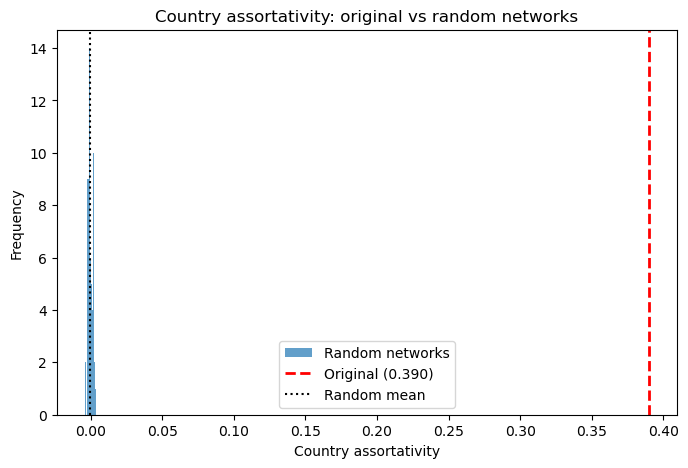

In [23]:
plt.figure(figsize=(8,5))

plt.hist(country_assort_random, bins=20, alpha=0.7, label="Random networks")

plt.axvline(r_country, color='red', linestyle='--', linewidth=2,
            label=f'Original ({r_country:.3f})')

plt.axvline(mean_rand, color='black', linestyle=':', label='Random mean')

plt.legend()
plt.xlabel("Country assortativity")
plt.ylabel("Frequency")
plt.title("Country assortativity: original vs random networks")

plt.show()

> __Part 4: Assortativity by Degree__
>
> 5. *Calculate degree assortativity* for your network using the formula discussed in the lecture.

Below we made afunction to calculate the degree assortativity discussed in the lecture:

In [24]:
def degree_assortativity_manual(G):
    """
    Manual degree assortativity for an undirected graph.
    Computes Pearson correlation between degrees at the ends of edges.
    """
    x = []
    y = []

    for u, v in G.edges():
        ku = G.degree(u)
        kv = G.degree(v)

        # count both directions for symmetry
        x.extend([ku, kv])
        y.extend([kv, ku])

    mean_x = sum(x) / len(x)
    mean_y = sum(y) / len(y)

    num = sum((a - mean_x) * (b - mean_y) for a, b in zip(x, y))
    den_x = sum((a - mean_x) ** 2 for a in x)
    den_y = sum((b - mean_y) ** 2 for b in y)

    if den_x == 0 or den_y == 0:
        return float("nan")

    return num / math.sqrt(den_x * den_y)

Using the above function we then calculated the requested degree assortativity:

In [25]:
r_degree_original = degree_assortativity_manual(G_gcc)
print("Original degree assortativity:", r_degree_original)

Original degree assortativity: -0.09761035311370908


> 6. *Compare your network's degree assortativity* against that of 100 random networks generated via the configuration model. Analyze whether your network shows a tendency for high-degree scientists to connect with other high-degree scientists and vice versa. 

Similarly to before with country assortativity, we generated 100 random networks and calculated the degree assortativity for each:

In [26]:
degree_assort_random = []

for i in range(100):
    if i % 10 == 0:
        print(f"{i}/100 done")

    G_rand = double_edge_swap_configuration_model_fast(G_gcc, seed=i)
    r_rand = degree_assortativity_manual(G_rand)
    degree_assort_random.append(r_rand)

0/100 done
Successful swaps: 502840/502840
Attempts: 506169
Successful swaps: 502840/502840
Attempts: 506183
Successful swaps: 502840/502840
Attempts: 506180
Successful swaps: 502840/502840
Attempts: 506257
Successful swaps: 502840/502840
Attempts: 506218
Successful swaps: 502840/502840
Attempts: 506130
Successful swaps: 502840/502840
Attempts: 506056
Successful swaps: 502840/502840
Attempts: 506223
Successful swaps: 502840/502840
Attempts: 506185
Successful swaps: 502840/502840
Attempts: 506238
10/100 done
Successful swaps: 502840/502840
Attempts: 506180
Successful swaps: 502840/502840
Attempts: 506301
Successful swaps: 502840/502840
Attempts: 506129
Successful swaps: 502840/502840
Attempts: 506122
Successful swaps: 502840/502840
Attempts: 506143
Successful swaps: 502840/502840
Attempts: 506189
Successful swaps: 502840/502840
Attempts: 506184
Successful swaps: 502840/502840
Attempts: 506219
Successful swaps: 502840/502840
Attempts: 506160
Successful swaps: 502840/502840
Attempts: 5062

We also calculated some statistics for this distribution:

In [27]:
mean_deg_rand = np.mean(degree_assort_random)
std_deg_rand = np.std(degree_assort_random)

print("Random mean:", mean_deg_rand)
print("Random std:", std_deg_rand)

z_deg = (r_degree_original - mean_deg_rand) / std_deg_rand
print("Z-score:", z_deg)

Random mean: -0.008217975644856965
Random std: 0.0041476989285443005
Z-score: -21.55228212290369


We then plotted the distribution. *Insert discussion*

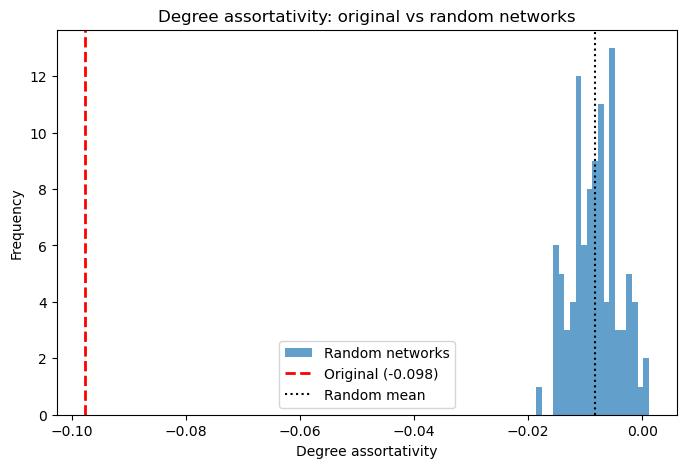

In [28]:
plt.figure(figsize=(8,5))

plt.hist(degree_assort_random, bins=20, alpha=0.7, label="Random networks")

plt.axvline(
    r_degree_original,
    color='red',
    linestyle='--',
    linewidth=2,
    label=f'Original ({r_degree_original:.3f})'
)

plt.axvline(
    mean_deg_rand,
    color='black',
    linestyle=':',
    label='Random mean'
)

plt.legend()
plt.xlabel("Degree assortativity")
plt.ylabel("Frequency")
plt.title("Degree assortativity: original vs random networks")
plt.show()

> __Part 5: Reflection questions__    
> 7. *Assortativity by degree.* Were the results of the degree assortativity in line with your expectations? Why or why not?    
> 8. *Edge flipping.* In the process of implementing the configuration model, you were instructed to flip the edges (e.g., changing $e_1$ from (u,v) to (v,u)) 50% of the time. Why do you think this step is included?    
> 9. *Distribution of assortativity in random networks.* Describe the distribution of degree assortativity values you observed for the random 
networks. Was the distribution pattern expected? Discuss how the nature of random network generation (specifically, the configuration model and edge flipping) might influence this distribution and whether it aligns with theoretical expectations.    


*Insert answers here*